# 02 Exploratory Data Analysis

This notebook combines visual churn analysis with analyst-style segment KPIs and revenue-at-risk views. The goal is to move beyond charts and identify the customer segments that matter most for retention.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.analytics import assign_monthly_charge_bucket, assign_tenure_bucket

sns.set_theme(style='whitegrid', palette='crest')
clean_df = pd.read_csv(DATA_DIR / 'processed' / 'clean_telco_churn.csv')
clean_df['churn_flag'] = (clean_df['Churn'] == 'Yes').astype(int)
clean_df['tenure_bucket'] = assign_tenure_bucket(clean_df['tenure'])
clean_df['monthly_charge_bucket'] = assign_monthly_charge_bucket(clean_df['MonthlyCharges'])
clean_df['monthly_revenue_at_risk'] = clean_df['MonthlyCharges'] * clean_df['churn_flag']
clean_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_flag,tenure_bucket,monthly_charge_bucket,monthly_revenue_at_risk
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 months,0-35,0.00
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,No,0,25-48 months,36-70,0.00
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 months,36-70,53.85
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 months,36-70,0.00
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 months,71-90,70.70


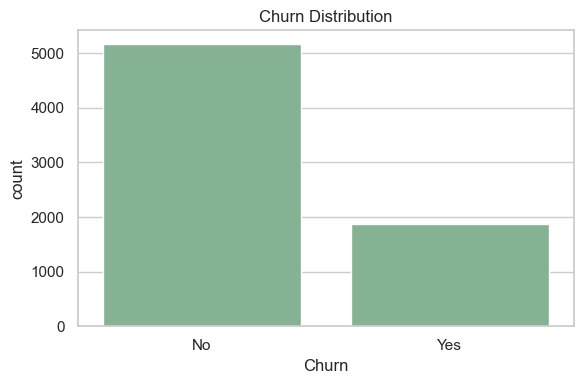

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=clean_df, x='Churn', ax=ax)
ax.set_title('Churn Distribution')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_churn_distribution.png', dpi=200)
plt.show()

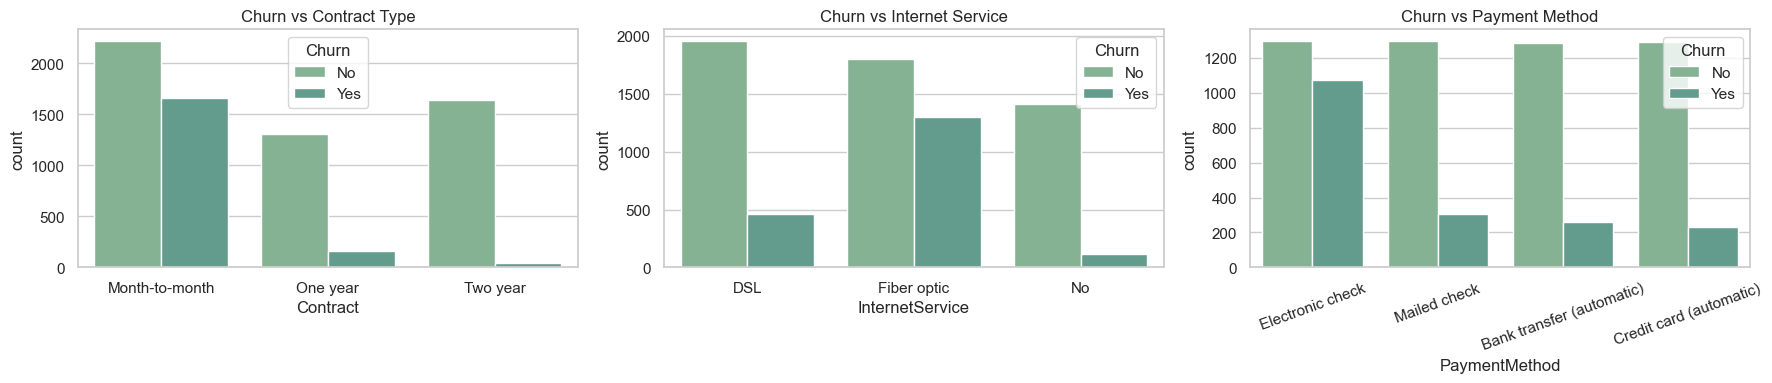

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(data=clean_df, x='Contract', hue='Churn', ax=axes[0])
axes[0].set_title('Churn vs Contract Type')
sns.countplot(data=clean_df, x='InternetService', hue='Churn', ax=axes[1])
axes[1].set_title('Churn vs Internet Service')
sns.countplot(data=clean_df, x='PaymentMethod', hue='Churn', ax=axes[2])
axes[2].set_title('Churn vs Payment Method')
axes[2].tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_core_segment_plots.png', dpi=200)
plt.show()

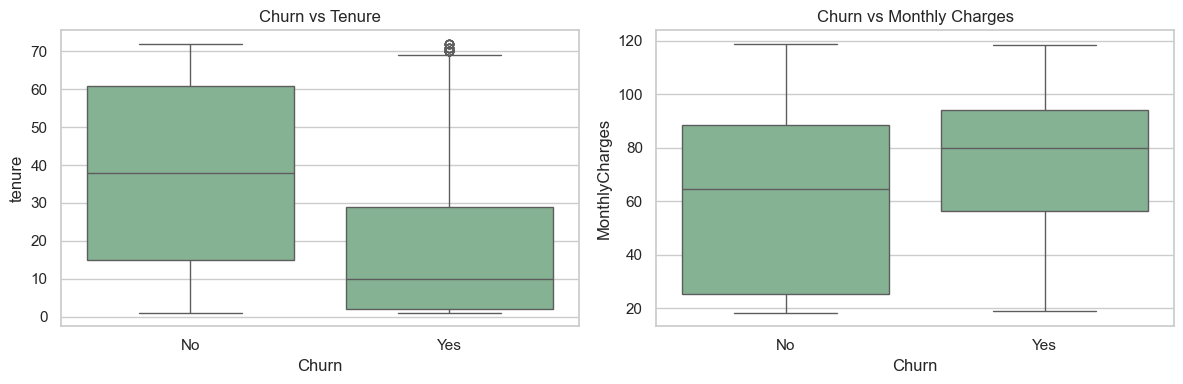

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=clean_df, x='Churn', y='tenure', ax=axes[0])
axes[0].set_title('Churn vs Tenure')
sns.boxplot(data=clean_df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Churn vs Monthly Charges')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_tenure_monthlycharges_boxplots.png', dpi=200)
plt.show()

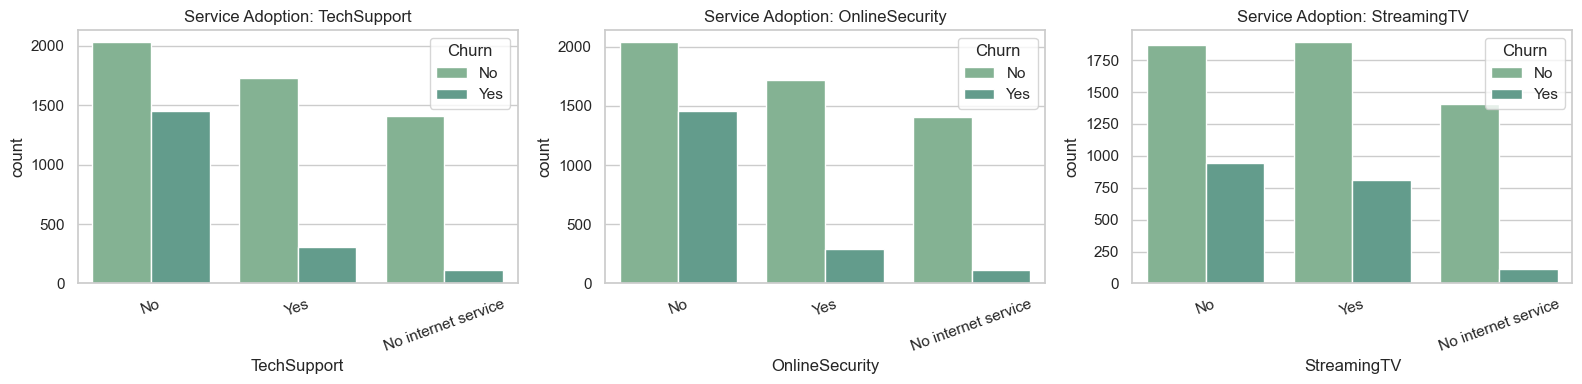

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, column in zip(axes, ['TechSupport', 'OnlineSecurity', 'StreamingTV']):
    sns.countplot(data=clean_df, x=column, hue='Churn', ax=ax)
    ax.set_title(f'Service Adoption: {column}')
    ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_service_adoption_patterns.png', dpi=200)
plt.show()

In [6]:
segment_dimensions = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'tenure_bucket', 'monthly_charge_bucket']
segment_rows = []
for dimension in segment_dimensions:
    grouped = clean_df.groupby(dimension, observed=False)
    summary = grouped.agg(
        customer_count=('churn_flag', 'size'),
        churn_count=('churn_flag', 'sum'),
        churn_rate=('churn_flag', 'mean'),
        monthly_revenue=('MonthlyCharges', 'sum'),
        monthly_revenue_at_risk=('monthly_revenue_at_risk', 'sum'),
        avg_monthly_charges=('MonthlyCharges', 'mean'),
    ).reset_index()
    summary['dimension'] = dimension
    summary = summary.rename(columns={dimension: 'segment'})
    segment_rows.append(summary)
segment_kpis = pd.concat(segment_rows, ignore_index=True)
segment_kpis = segment_kpis.sort_values(['monthly_revenue_at_risk', 'churn_rate'], ascending=False)
segment_kpis.head(15)

,segment,customer_count,churn_count,churn_rate,monthly_revenue,monthly_revenue_at_risk,avg_monthly_charges,dimension
0,Month-to-month,3875,1655,0.427097,257294.15,120847.10,66.398490,Contract
4,Fiber optic,3096,1297,0.418928,283284.40,114300.05,91.500129,InternetService
10,No,3472,1446,0.416475,258958.70,110709.80,74.584879,TechSupport
8,Electronic check,2365,1071,0.452854,180345.00,84288.75,76.255814,PaymentMethod
13,0-12 months,2175,1037,0.476782,122174.15,68954.25,56.172023,tenure_bucket
20,90+,1739,570,0.327775,175671.50,56784.10,101.018689,monthly_charge_bucket
19,71-90,1842,697,0.378393,147476.60,55706.90,80.063301,monthly_charge_bucket
15,25-48 months,1594,325,0.203890,105093.30,27462.50,65.930552,tenure_bucket
12,Yes,2040,310,0.151961,164666.35,26119.45,80.718799,TechSupport
14,13-24 months,1024,294,0.287109,62829.85,23081.65,61.357275,tenure_bucket


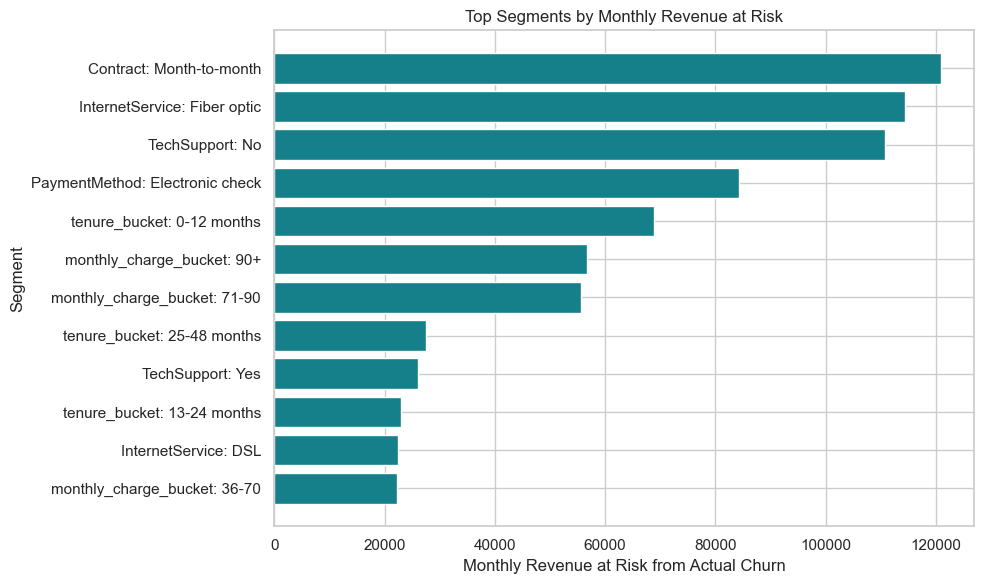

In [7]:
priority_segments = segment_kpis.head(12).copy()
priority_segments['segment_label'] = priority_segments['dimension'] + ': ' + priority_segments['segment'].astype(str)
priority_segments = priority_segments.sort_values('monthly_revenue_at_risk')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(priority_segments['segment_label'], priority_segments['monthly_revenue_at_risk'], color='#157f8a')
ax.set_title('Top Segments by Monthly Revenue at Risk')
ax.set_xlabel('Monthly Revenue at Risk from Actual Churn')
ax.set_ylabel('Segment')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_segment_revenue_at_risk.png', dpi=200)
plt.show()

In [8]:
tenure_kpi = segment_kpis[segment_kpis['dimension'] == 'tenure_bucket'][['segment', 'customer_count', 'churn_rate', 'monthly_revenue_at_risk']]
payment_kpi = segment_kpis[segment_kpis['dimension'] == 'PaymentMethod'][['segment', 'customer_count', 'churn_rate', 'monthly_revenue_at_risk']]
display(tenure_kpi.sort_values('churn_rate', ascending=False))
payment_kpi.sort_values('monthly_revenue_at_risk', ascending=False)

,segment,customer_count,churn_rate,monthly_revenue_at_risk
13,0-12 months,2175,0.476782,68954.25
14,13-24 months,1024,0.287109,23081.65
15,25-48 months,1594,0.203890,27462.50
16,49+ months,2239,0.095132,19632.45


,segment,customer_count,churn_rate,monthly_revenue_at_risk
8,Electronic check,2365,0.452854,84288.75
6,Bank transfer (automatic),1542,0.167315,20091.90
7,Credit card (automatic),1521,0.152531,17946.60
9,Mailed check,1604,0.192020,16803.60


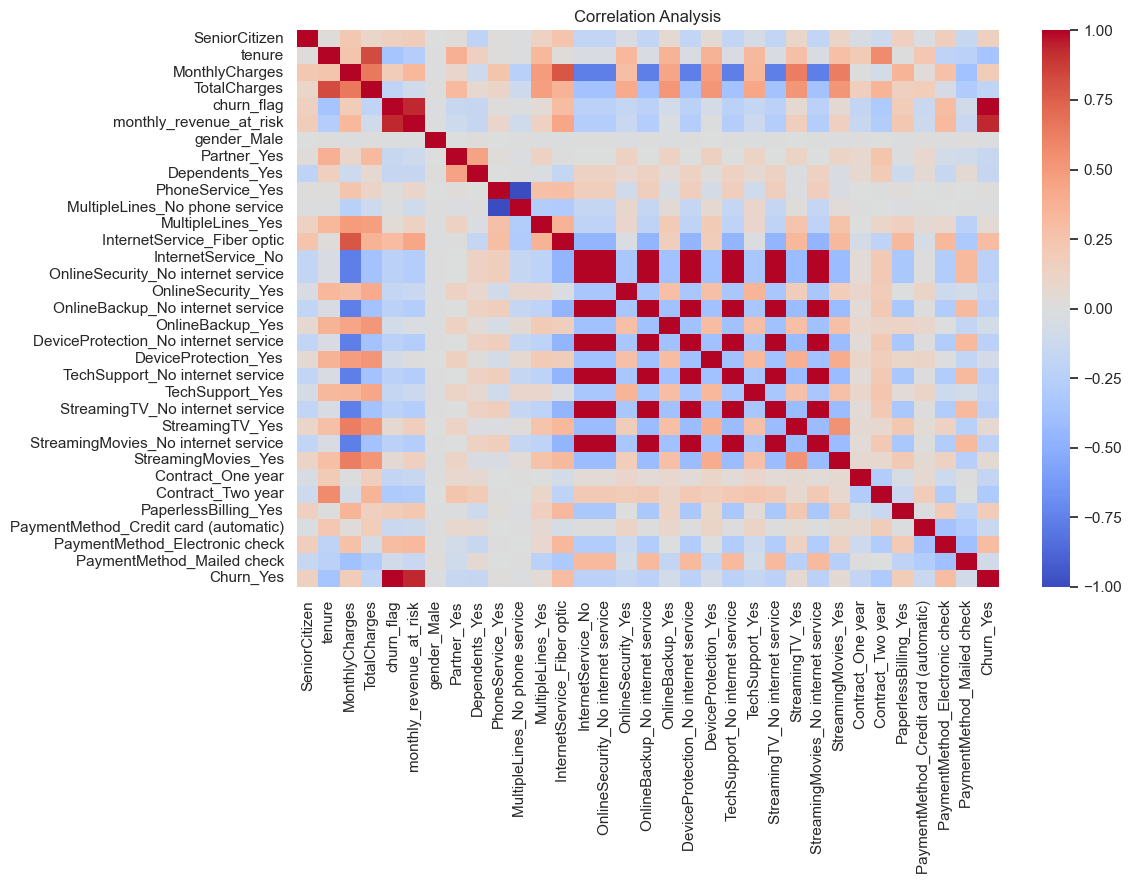

In [9]:
corr_df = clean_df.drop(columns=['tenure_bucket', 'monthly_charge_bucket']).copy()
corr_df = pd.get_dummies(corr_df, drop_first=True)
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_df.corr(numeric_only=True), cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Analysis')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_correlation_heatmap.png', dpi=200)
plt.show()

## Key Insights Summary

- Contract structure is the strongest business lever. Month-to-month customers show the highest churn rate and the largest concentration of revenue at risk.
- Short-tenure customers are materially more fragile than mature customers, especially in the first 12 months.
- Fiber optic customers and electronic check users combine elevated churn with meaningful revenue exposure, making them strong intervention segments.
- Lack of technical support and security services consistently maps to higher churn, suggesting retention upside through service bundling and onboarding support.